Nesse modulo vai ser abordado o Projeto de predição de carro usando regressão linear.
Para treinar um modelo é preciso de um grande acervo de dados, existe um site chamado Kaggle.

1 -O plano sera pegar dados e analisar eles, compreender as informações;

2 -Preparar os dados e treinar o modelo de regressão linear e prever o MSRP(Valor sugerido do fabricante)

3 -Avaliar o modelo com RMSE( Raiz do erro quadratico médio) - Como se fosse um erro médio do modelo.
Quanto menor o RMSE melhor a avaliação. Um desvio medio entre o valor real e o previsto.

4 -Crias novas features para nosso modelo, novas caractéristicas que podemos usar.

5 -Lidar com alguns problemas de cálculos e como resolver com regularization.

6 - Usar o modelo.


In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv')

# df.columns.str.lower().str.replace(' ', '_')
# assim substituimos nas colunas o espaço entre palavras para '_' e todas as letras minusculas
# isso para podermos fazer a associação de colunas sem erros por letra maiuscula
# e outro problema é quando possui uma letra com ' ' - espaço, existem várias funções que
# não funcionam devido ao espaço entre as palavras.
df.columns = df.columns.str.lower().str.replace(' ', '_')
# Também precisamos padronizar as informações nas linhas/rows onde seria nesse exemplo seria os carros.
df.dtypes
# vemos o tipo de dados que estão armazenados em cada coluna para transformar apenas as strings.
strings = list(df.dtypes[df.dtypes == 'string'].index)
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')
# Agora com colunas e informações padronizadas, podemos compreender mais as informações que temos
# Primeiramente verificar em cada coluna os itens unicos que temos em cada coluna.
for col in df.columns:
    # Primeiro exibimos para cada coluna o nome da coluna, as informações unicas quantas informações unicas possui.
    print(col)
    print(df[col].unique())
    print(df[col].nunique())
    print()

make
<StringArray>
[          'bmw',          'audi',          'fiat', 'mercedes-benz',
      'chrysler',        'nissan',         'volvo',         'mazda',
    'mitsubishi',       'ferrari',    'alfa_romeo',        'toyota',
       'mclaren',       'maybach',       'pontiac',       'porsche',
          'saab',           'gmc',       'hyundai',      'plymouth',
         'honda',    'oldsmobile',        'suzuki',          'ford',
      'cadillac',           'kia',       'bentley',     'chevrolet',
         'dodge',   'lamborghini',       'lincoln',        'subaru',
    'volkswagen',        'spyker',         'buick',         'acura',
   'rolls-royce',      'maserati',         'lexus',  'aston_martin',
    'land_rover',         'lotus',      'infiniti',         'scion',
       'genesis',        'hummer',         'tesla',       'bugatti']
Length: 48, dtype: str
48

model
<StringArray>
[  '1_series_m',     '1_series',          '100',   '124_spider',
    '190-class',     '2_series',         

In [3]:
df.head()


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [4]:
# Matplotlib e Seaborn São duas bibliotecas que serão usados para visualização desse dados
# de uma forma com maior design.
import matplotlib.pyplot as plt
# Usado para representação de gráficos e estatísticas.
import seaborn as sns
# Uma biblioteca de alto nivel baseada no matplotlib usada para automatizar visualizações de estatísticas complexas
# com uma aparencia mais limpa e padronizada.
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

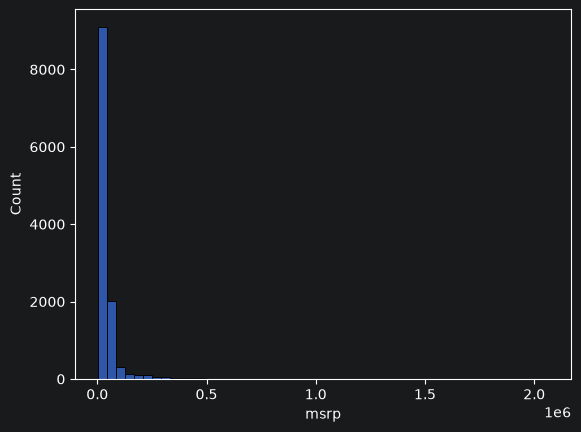

In [5]:
sns.histplot(df.msrp,bins=50) # bins sendo o tanto de barras que deseja visualizar

<Axes: xlabel='msrp', ylabel='Count'>

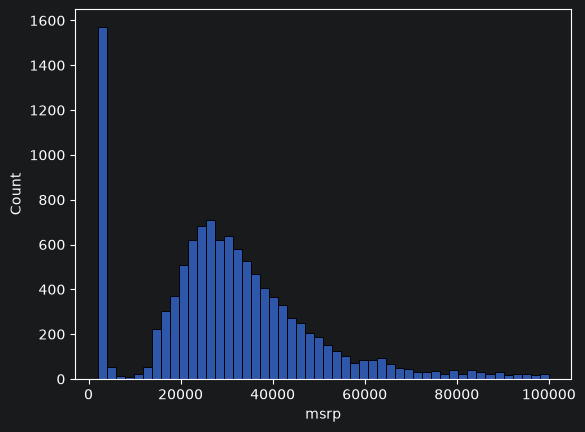

In [6]:
sns.histplot(df.msrp[df.msrp < 100000],bins=50) # Outra forma é usar filtros para vermos em escopo mais aproximado.

In [7]:
# Como vemos em no gráfico possui vários valores para um carro, sendo carros de luxo muito caros, e assim sendo em uma menor quantidade e valores estranhamente abaixo normal, esses valores desproporcionais podem afetas o modelo
# Aplicaremos um logaritmo nos valores com a função de numpy np.log1p() que alem de fazer o logaritmo adiciona +1 em todos os seus valores para não haver erro caso haja um 0 entre os numeros.
preco_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

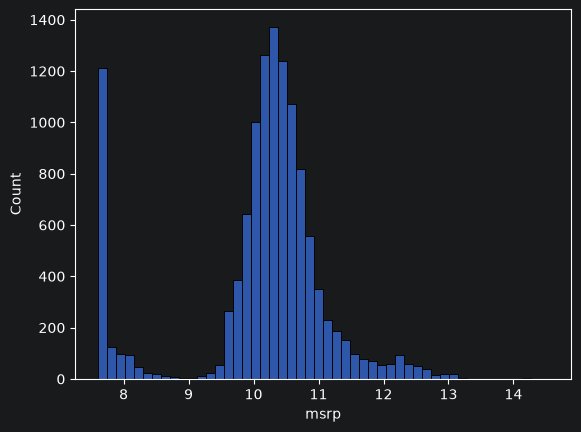

In [8]:
sns.histplot(preco_logs, bins=50)
# vemos que possui uma distribuição padrao no meio dos preços, a cauda de valores exorbitantes diminui junto com os valores estranhamente menores de 1000$ também diminui em relação ao padrao.
# esse pico de valor baixo pode ser analisado para ser compreendido.
# Mas geralmente uma distribuição padrao como essa é ideal para os modelos de predição

In [9]:
# Verificando os valores nulos com .isnull()-Retorna true para valor nulo e .sum() - ira somar quantos true tem em cada coluna.
df.isnull().sum()
# Temos que estar atentos a essa falta de informação quando for feito o treino do modelo.

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [10]:
# Criando o campo de validação do modelo:
# Com os dados que temos separamos entre dados de treino, de validação e de teste
# Separando-os em 3 matrizes e targets. Geralmente na proporção 60% 20% 20%.
n = len(df)
# Primeiro precisamos saber quantos linhas de dados temos para fazer essa divisão.

vali_n = int(n*0.2)
test_n = int(n*0.2)
train_n = n - vali_n - test_n
# Atribuindo uma variavel ao tanto de linhas que queremos separar.
# Agora que sabemos o tamanho que precisamos separar do data frame. Usando iloc que retorna a linha baseada em indexação. iloc(start,stop)
df_train = df.iloc[:train_n] #Sendo o resto do total.
df_vali = df.iloc[train_n:train_n + vali_n] #vali_n sendo 2382
df_test = df.iloc[train_n + vali_n:] # test_n sendo 2382,
# Precisamos randomizar as linhas dos dados, devido a estar por alguma ordem alfabetica ou modelo.
idx = np.arange(n) # n sendo todas as linhas

# Por aprendizado vai ser setado uma seed onde vai ser alterado randomicamente mas reproduzivel.
np.random.seed(2)
np.random.shuffle(idx)

df_train = df.iloc[idx[train_n:]]
df_vali = df.iloc[idx[train_n:train_n + vali_n]]
df_test = df.iloc[idx[train_n + vali_n:]]


In [11]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
10498,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
1880,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
11798,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
6637,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
2575,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [12]:
# Como os numeros de index aparecem ao lado esquerdo de forma desordenada devido ao randomizar.
df_train = df_train.reset_index(drop=True)
df_vali = df_vali.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
# Assim formatamos a indexação dos nossos campos randomizados e separados.
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
4760,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
4761,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
4762,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [13]:
# Criando a variavel y a partir dos preços dos campos de validação usando logaritimo + 1.
y_train = np.log1p(df_train.msrp.values)
y_vali = np.log1p(df_vali.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [14]:
# Para prevermos o valor do preço, não podemos ter esse valor, se não o modelo iria ficar inviesado e talvez não fosse eficaz com novos valores da realidade.
# Então apagamos a coluna de preço
del df_train['msrp']
del df_vali['msrp']
del df_test['msrp']

                                    REGRESSÃO LINEAR
Basicamente usamos modelo de regressão linear para retornar números que queremos prever.
A função de modelo como ja vi anteriormente é g(X)~=y.
g o modelo e x sendo a matriz de rows que iremos usar e y sendo o target


In [15]:
# Vamos dar uma analisada nas features que temos para poder utilizar no treinamento desse modelo.
df_train.iloc[10]

make                                      gmc
model                                  savana
year                                     2014
engine_fuel_type     flex-fuel_(unleaded/e85)
engine_hp                               310.0
engine_cylinders                          8.0
transmission_type                   automatic
driven_wheels                 all_wheel_drive
number_of_doors                           3.0
market_category                     flex_fuel
vehicle_size                          midsize
vehicle_style                   passenger_van
highway_mpg                                17
city_mpg                                   13
popularity                                549
Name: 10, dtype: object

Nesse exemplo pegamos 'city_mpg', popularity e engine_hp de um carro especifico.
Então a matriz X de rows dentro do modelo seria Xi = [13, 549, 310]

E um exemplo de modelo seria:

def g(Xi):
    return 10000

g(xi)
    10000

Mas como seria essa implementão na pratica na realidade?
A formula da regressão linear
g(xi)=WO+W1*Xi1+W2*Xi2+W3*Xi3

Wo = (Bias) a predição queremos realizar sem saber nada do target
é uma constante inicial do modelo quando não possui elementos na matriz X é igual 0.

Medidas para o modelo:
W1 = (Atribuimos uma medida de 'importância' para o elemento que possuímos.)

Xi1 = (Os elementos de entrada que utilizaremos:)

W2,Xi2 = elementos consecutivamente.

In [16]:
xi = [310, 13, 549]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [17]:
def regressao_linear(xi):
    n = len(xi) # atribui n a quantidade de elementos

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j] # Com
    return pred
regressao_linear(xi)
np.expm1(11.888)
np.log1p(145508.98664882887)

np.float64(11.888)

Agora realizando essa mesma formula pensando em vetores e no produto .dot() multiplicação de matrizes.


In [18]:
def dot(xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]
    return res
def linear_regression(xi):
    return w0 + dot(xi, w)

In [19]:
novo_w = [w0] + w

In [20]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, novo_w)

In [21]:
linear_regression(xi)
# Teste de formula mais reduzida

11.888

In [22]:
x1 = [1,148,24,1385]
x2 = [1,132,25,2031]
x10 = [1,453,11,86]
X = [x1 , x2 , x10]
# Atribuindo múltiplas linhas a lista X
X = np.array(X)
# Criação de matriz com listas

Agora uma forma mais resumida da formula onde poderemos aplicar em multiplas rows:
Como dito anteriormente X é matriz de linhas/rows que nosso modelo usará para prever y

In [23]:

def linear_regression(X):
    return X.dot(novo_w)
# W na proxima aula o Alexey vai detalhar mais sobre o que é o w





O alexey fala sobre uma equação para treino de regressão linear com a formula sendo

W (o target que é o mais proximo de y a realidade.)

w0 (bias term - valor constante colocado no modelo usado para ajudar a encaixar corretamente os dados)

XTX(o produto da matriz X transposta com X)

XTX_inv( A inversão de desse produto)

XTX_inv.dot(XTX) (O produto da inversada com o matriz XTX.)


     W = (XTX)-¹ * XT Y






In [24]:

def train_linear_regression(X,y):
    pass

In [25]:
X = ([[148,24,135],
[132,25,201],
[43,11,86],
[14,24,135],
[12,925, 83],
[53,1671,86],
[458,424,1385],
[12,25,2031],
[453,11,86]])

# como feito na atividade no modulo 1.
X = np.array(X)
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
XTX_inv.dot(XTX).round(1)

array([[ 1., -0.,  0.],
       [ 0.,  1.,  0.],
       [-0.,  0.,  1.]])

In [26]:
# one = np.ones(X.shape[0])
# X = np.column_stack([one,X]).round(1)

In [27]:
X = np.array(X)
XTX = X.T.dot(X)
XTX_inv = np.linalg.inv(XTX)
XTX_inv.dot(XTX).round(1)

y = [100,200,150,250,100,200,150,250,120]
w_full = XTX_inv.dot(X.T).dot(y)
w0 = w_full[0]
w = w_full[1:]

In [28]:
def train_linear_regression(X,y):
    one = np.ones(X.shape[0])
    X = np.column_stack([one,X]).round(1)
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [29]:
train_linear_regression(X, y)

(np.float64(176.65489513637323),
 array([-0.15418715, -0.00697147,  0.0369665 ]))



Com isso não precisamos ficar adicionando +1 em todos os pesos como antes. Pois já está dentro dessa função.

Agora reunindo os dados que precisamos usar nessa equação, visualizando as colunas temos:

'engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity'

Com esses dados Vamos criar uma base para o nosso modelo




















In [30]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']
df_train[base] # para visualizar apenas as colunas listada.

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,200.0,4.0,25,19,1385
1,241.0,4.0,29,22,617
2,160.0,4.0,36,26,5657
3,290.0,6.0,34,21,204
4,170.0,4.0,34,25,873
...,...,...,...,...,...
4759,200.0,6.0,18,13,1385
4760,160.0,4.0,33,29,640
4761,250.0,6.0,22,15,1851
4762,174.0,4.0,42,31,2202


In [31]:
X_train = df_train[base].values
# Dentro desses dados possui algums faltantes com isso eliminamos com fillna e o modelo ira ignorar esse valor
# As vezes em um modelo não é a forma correta de se fazer.
X_train = df_train[base].fillna(0).values

In [32]:
w0, w = train_linear_regression(X_train, y_train)

In [33]:
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

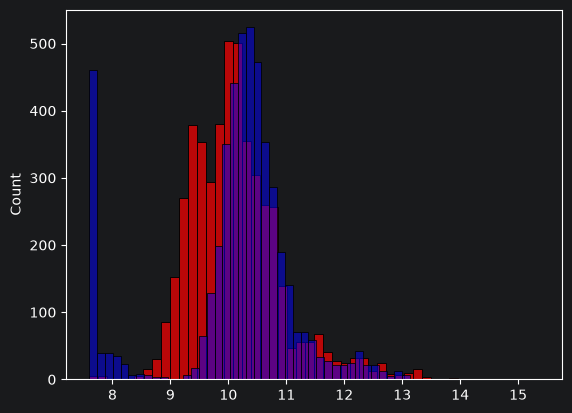

In [34]:
sns.histplot(y_pred, color='red', alpha =0.7, bins=50)
sns.histplot(y_train, color='blue', alpha =0.5, bins=50)

In [35]:
# Analisando os graficos vemos que o modelo não foi muito acertivo. Mas precisamos avaliar não apenas no grafico e sim em com uma formula.
# Root Mean Squared Error
# g(xi) - yi seria a predição menos o valor real
# g(y_pred) - y_train
# Gerara um array com as diferenças desses valores. e elevamos ao quadrado.
# Pegamos a média desses valores e fazemos uma raiz quadrada.

In [36]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error **2
    return np.sqrt(np.mean(se))

In [37]:
rmse(y_train, y_pred)
# Mas o passo a passo correto seria usar os dados de treino para o treino do modelo e aplicar nos dados de validação e assim aplicar RMSE no resultado.

np.float64(0.7415514275559719)

In [38]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X
# Essa função prepara a matriz com base nas colunas [base], onde iremos usar essa função para extrair essas informações que preenchera a matriz de treino , validação e posteriormente matriz de teste.
# Com a função tratando isso partiremos para o RMSE de validação.

In [39]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
# A matriz de treino para o aprendizado de maquina.

X_val = prepare_X(df_vali)
# O valor que usamos para validar o treino

y_pred = w0 + X_val.dot(w)
# A predição com esse valor do treino usado em validação.

rmse(y_vali, y_pred)
# avaliação.

np.float64(0.7517221959226251)

In [40]:
# Adicionando mais features para aumentar precisão.
# Em um exemplho pratico real uma feature muito importante em um carro seria o ano de fabricação. Ele geralmente tem um grande peso no seu valor. O ano de coleta desse banco de dados é 2017, logo os dados so vao até 2017
df_train.year.max()
# para vermos a data maxima

np.int64(2017)

In [41]:
# Com isso vamos adicionar essa feature ao banco de dados, realizando 2017 menos o ano do carro.
# Assim dando uma idade de quanto o tempo esse carro foi criado. E criamos um dataframe com essas features.
def prepare_X(df):
    df = df.copy() # Para não afetar o dataframe original, criamos uma copia para realizar na função.
    df['age'] = 2017 - df.year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [42]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
# A matriz de treino para o aprendizado de maquina.

X_val = prepare_X(df_vali)
# O valor que usamos para validar o treino

y_pred = w0 + X_val.dot(w)
# A predição com esse valor do treino usado em validação.

rmse(y_vali, y_pred)
# avaliação.
# Vemos que houve uma grande melhoria nos erros mas ainda não está em um nivel aceitavel.

np.float64(0.5162117360740246)

<Axes: ylabel='Count'>

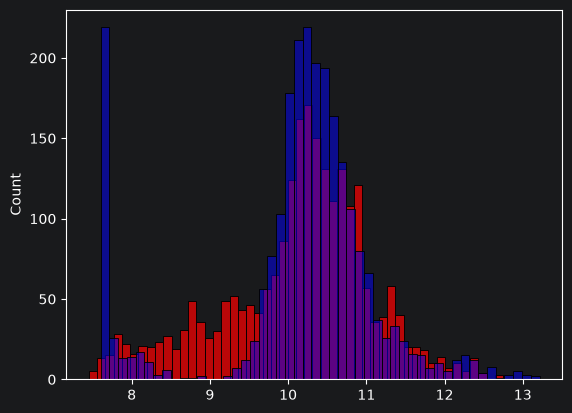

In [43]:
sns.histplot(y_pred, color='red', alpha =0.7, bins=50)
sns.histplot(y_vali, color='blue', alpha =0.5, bins=50)

In [44]:
# Variaveis categorias = Onde reconhecemos por string s
# Mais uma feature listada seria o numero de portas onde geralmente observamos que os carros de luxo geralmente
# possuem apenas 2 portas , e carros populares 3,4. Onde na lista se fala entre carros de 2,3,4 portas.
# Para não fazer uma feature para cada quantidade de porta é usado a função for.

#for v in [2,3,4]:
#    df_train['number_doors_%s' % v] = (df.number_of_doors == v).astype('int)
#    features.append('number_doors_%s' % v)

In [45]:
def prepare_X(df):
    df = df.copy() # Para não afetar o dataframe original, criamos uma copia para realizar na função.
    features = base.copy()
    # Realizando mais adição de features, é interessante realizar uma cópia das features originais.
    # E assim a função de preparar a matriz ir adicionando essas features para ser usado na avaliação.
    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3, 4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int64')
        features.append('num_doors_%s' % v) # %s é formatado na string para v
    # Assim para cada loop cria uma feature que sera adicionada a lista de features, mostrando quantas portas possui.
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [46]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_vali)
y_pred = w0 + X_val.dot(w)

rmse(y_vali, y_pred)

np.float64(16.436445417203185)

In [47]:
w0, w = train_linear_regression(X_train, y_train)

In [48]:
print("w0 =", w0)
print("w =", w)

w0 = -103.47648552744789
w = [ 6.47352114e-02  5.32793590e+00  4.93960698e+00 -3.03645051e+00
  1.50712424e-03  1.04338689e+00 -1.14275872e+01  3.49287860e+00
 -1.58613200e+00]


In [49]:
print(np.linalg.cond(X_train.T.dot(X_train)))

1220089154.397596


In [50]:
print(df_train['number_of_doors'].value_counts())

number_of_doors
4.0    3353
2.0    1244
3.0     167
Name: count, dtype: int64


In [51]:
def prepare_X(df):
    df = df.copy() # Para não afetar o dataframe original, criamos uma copia para realizar na função.
    features = base.copy()
    # Realizando mais adição de features, é interessante realizar uma cópia das features originais.
    # E assim a função de preparar a matriz ir adicionando essas features para ser usado na avaliação.
    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int64')
        features.append('num_doors_%s' % v) # %s é formatado na string para v
    # Assim para cada loop cria uma feature que sera adicionada a lista de features, mostrando quantas portas possui.
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [52]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_vali)
y_pred = w0 + X_val.dot(w)

rmse(y_vali, y_pred)

np.float64(0.5147771273514313)

In [ ]:
#Tive problemas com o modelo quando coloquei portas 2,3,4 no loop v, dei uma pesquisada e é uma coisa chamada multicolineariaridade perfeita ou a dummy variable trap. Onde nosso modelo ja possui o bias term W0 onde adiciona +1 e torna a informaçao de mais 1 porta redundante, retirando 1 porta do loop fica reconhecido que a porta é o valor que não foi denominado logo 0,0.

<Axes: ylabel='Count'>

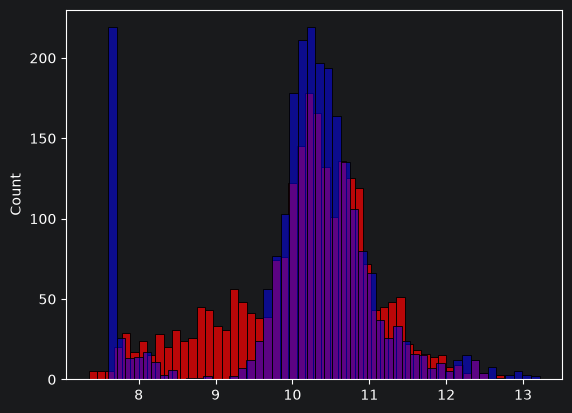

In [54]:
sns.histplot(y_pred, color='red', alpha =0.7, bins=50)
sns.histplot(y_vali, color='blue', alpha =0.5, bins=50)

In [56]:
# listando os 5 carros mais populares por fabricante:
makes = list(df.make.value_counts().head().index)

In [61]:
def prepare_X(df):
    df = df.copy() # Para não afetar o dataframe original, criamos uma copia para realizar na função.
    features = base.copy()
    # Realizando mais adição de features, é interessante realizar uma cópia das features originais.
    # E assim a função de preparar a matriz ir adicionando essas features para ser usado na avaliação.
    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v) # %s é formatado na string para v
    # Assim para cada loop cria uma feature que sera adicionada a lista de features, mostrando quantas portas possui.
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)
    # adicionando as fabricantes por features e alocando um numero binario para cada um.
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [62]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_vali)
y_pred = w0 + X_val.dot(w)

rmse(y_vali, y_pred)
# as coisas tão melhorando de pouco em pouco

np.float64(0.5059045353010894)

<Axes: ylabel='Count'>

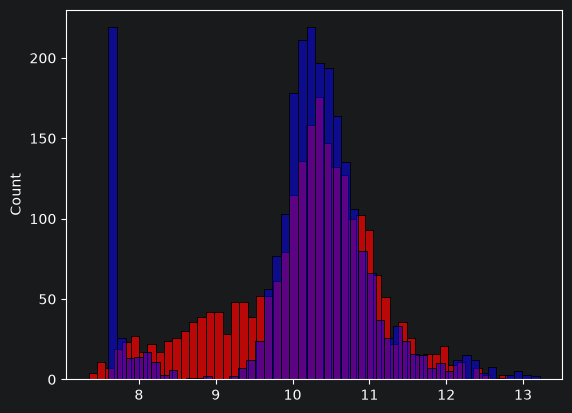

In [63]:
sns.histplot(y_pred, color='red', alpha =0.7, bins=50)
sns.histplot(y_vali, color='blue', alpha =0.5, bins=50)

In [65]:
# Agora realizando isso em uma escala maior com o resto dos dados.
categorical_variables = ['make', 'engine_fuel_type','transmission_type','driven_wheels','market_category','vehicle_size', 'vehicle_style']

In [66]:
# criando um dicionarios com essa lista
categories = {}
for c in categorical_variables:
    categories[c] = list(df[c].value_counts().head().index)

In [68]:
def prepare_X(df):
    df = df.copy() # Para não afetar o dataframe original, criamos uma copia para realizar na função.
    features = base.copy()
    # Realizando mais adição de features, é interessante realizar uma cópia das features originais.
    # E assim a função de preparar a matriz ir adicionando essas features para ser usado na avaliação.
    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2, 3]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v) # %s é formatado na string para v
    # Assim para cada loop cria uma feature que sera adicionada a lista de features, mostrando quantas portas possui.
    for v in makes:
        df['make_%s' % v] = (df.make == v).astype('int')
        features.append('make_%s' % v)
    # adicionando as fabricantes por features e alocando um numero binario para cada um.

    for c , values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [69]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_vali)
y_pred = w0 + X_val.dot(w)

rmse(y_vali, y_pred)

np.float64(6940.614020812025)